# **Fruits-360 CNN**

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, precision_recall_fscore_support
import matplotlib.pyplot as plt
import numpy as np
import gc

IMG_SIZE = (100, 100)
BatchSize = 32
SEED = 123

train_path = "/kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Training"
test_path = "/kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Test"

2026-06-13 16:29:00.495056: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781368140.661381      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781368140.709357      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781368141.128083      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781368141.128121      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781368141.128123      23 computation_placer.cc:177] computation placer alr

In [2]:
keras.backend.clear_session()
gc.collect()

train_ds = keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BatchSize,
    color_mode="rgb",
    label_mode="categorical",
    shuffle=True,
)

val_ds = keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BatchSize,
    color_mode="rgb",
    label_mode="categorical",
    shuffle=True,
)

num_classes = len(train_ds.class_names)
print("Jumlah kelas:", num_classes)

Found 137221 files belonging to 260 classes.
Using 109777 files for training.


I0000 00:00:1781368274.088464      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781368274.094570      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 137221 files belonging to 260 classes.
Using 27444 files for validation.
Jumlah kelas: 260


In [3]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomZoom(0.3),
    layers.RandomRotation(0.1),
], name="data_augmentation")

In [4]:
def train_model(model):
    model.compile(
        loss="categorical_crossentropy",
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        metrics=["accuracy"],
    )
    
    stop_early = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    )
    
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        callbacks=[stop_early],
    )

    return history

In [5]:
def plot_history(history):
    h = history.history
    epochs = range(1, len(h["loss"]) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, h["loss"], "o-", label="Train loss")
    ax1.plot(epochs, h["val_loss"], "o-", label="Val loss")
    ax1.set_title("Loss vs Epochs")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, h["accuracy"], "o-", label="Train acc")
    ax2.plot(epochs, h["val_accuracy"], "o-", label="Val acc")
    ax2.set_title("Accuracy vs Epochs")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 260)            │        33,540 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,788 (495.27 KB)

 Trainable params: 126,788 (495.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15


I0000 00:00:1781368302.433768      76 cuda_dnn.cc:529] Loaded cuDNN version 91002


3431/3431 ━━━━━━━━━━━━━━━━━━━━ 275s 79ms/step - accuracy: 0.4837 - loss: 1.9250 - val_accuracy: 0.8814 - val_loss: 0.4145
Epoch 2/15
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - accuracy: 0.7962 - loss: 0.6143 - val_accuracy: 0.9307 - val_loss: 0.2223
Epoch 3/15
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - accuracy: 0.8474 - loss: 0.4498 - val_accuracy: 0.9536 - val_loss: 0.1542
Epoch 4/15
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - accuracy: 0.8734 - loss: 0.3678 - val_accuracy: 0.9494 - val_loss: 0.1544
Epoch 5/15
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - accuracy: 0.8872 - loss: 0.3225 - val_accuracy: 0.9609 - val_loss: 0.1211
Epoch 6/15
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - accuracy: 0.8994 - loss: 0.2867 - val_accuracy: 0.9650 - val_loss: 0.0983
Epoch 7/15
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - accuracy: 0.9074 - loss: 0.2626 - val_accuracy: 0.9675 - val_loss: 0.0922
Epoch 8/15
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - accuracy: 0.9153 - loss: 0.2

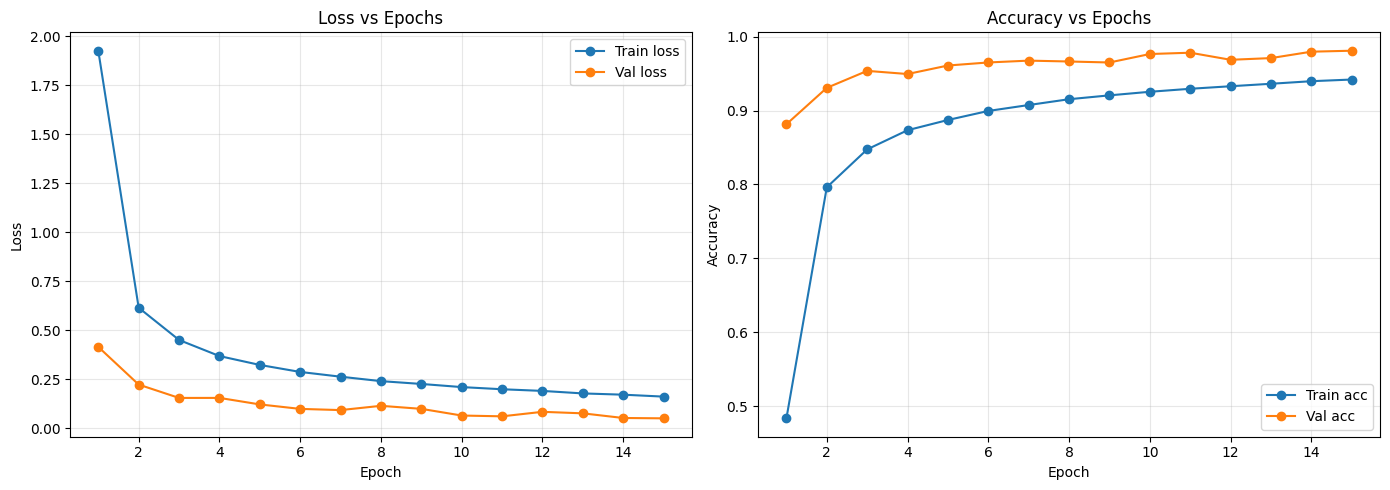

In [6]:
model = keras.Sequential([
    keras.Input(shape=(100, 100, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax"),
])

model.summary()
history = train_model(model)
plot_history(history)
model.save("Fruits360-CustomCNN.keras")


/tmp/ipykernel_23/2922144936.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 260)            │       333,060 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,591,044 (9.88 MB)

 Trainable params: 333,060 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/15
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 75s 20ms/step - accuracy: 0.7227 - loss: 1.0440 - val_accuracy: 0.8724 - val_loss: 0.4200
Epoch 2/15
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 68s 20ms/step - accuracy: 0.8360 - loss: 0.5768 - val_accuracy: 0.8952 - val_loss: 0.3628
Epoch 3/15
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 68s 20ms/step - accuracy: 0.8570 - loss: 0.5301 - val_accuracy: 0.9114 - val_loss: 0.2763
Epoch 4/15
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 68s 20ms/step - accuracy: 0.8672 - loss: 0.5072 - val_accuracy: 0.9162 - val_loss: 0.2621
Epoch 5/15
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 68s 20ms/step - accuracy: 0.8763 - loss: 0.4888 - val_accuracy: 0.9091 - val_loss: 0.3153
Epoch 6/15
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 68s 20ms/step - accuracy: 0.8802 - loss: 0.4901 - val_accuracy: 0.9245 - val_loss: 0.2437
Epoch 7/15
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 68s 20ms/step - accuracy: 0.8858 - loss: 0.4779 - val_accuracy: 0.9285 - val_loss: 0.2265
Epoch 8/15
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 68s 20ms/step - accuracy: 0.8869 -

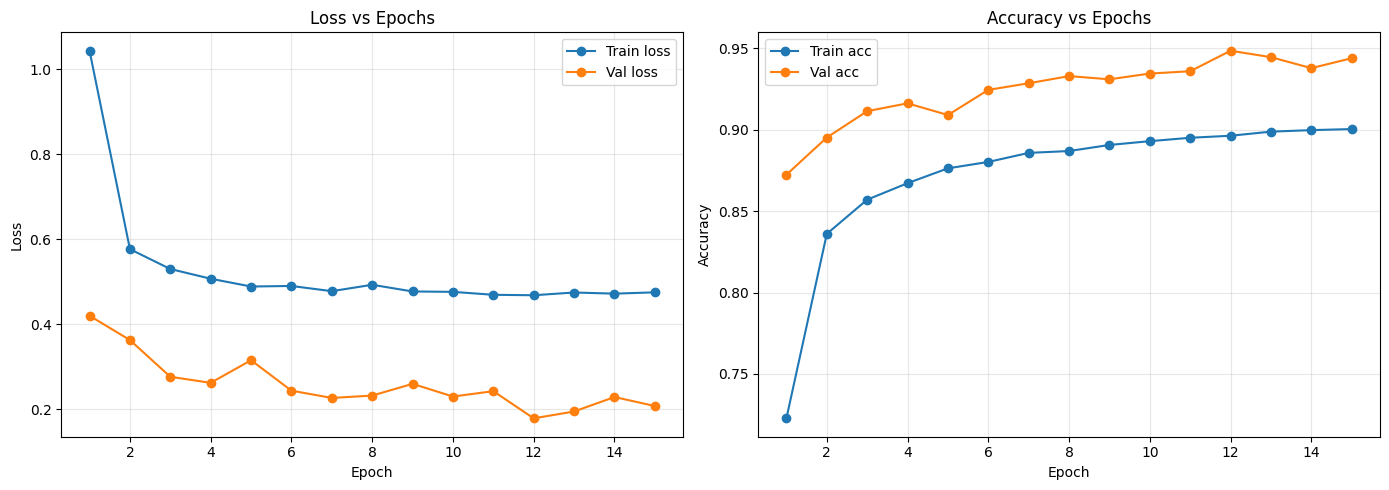

In [7]:
base_model = MobileNetV2(
    input_shape=(100, 100, 3),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

model = keras.Sequential([
    keras.Input(shape=(100, 100, 3)),
    data_augmentation,
    layers.Rescaling(1./127.5, offset=-1),

    base_model,

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax"),
])

model.summary()
history = train_model(model)
plot_history(history)
model.save("Fruits360-MobileNetV2.keras")

In [8]:
keras.backend.clear_session()
gc.collect()

test_ds = keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BatchSize,
    color_mode="rgb",
    label_mode="categorical",
    shuffle=False,
)

class_names = test_ds.class_names
test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

Found 45724 files belonging to 260 classes.


In [9]:
def evaluate_model(model_path, name):
    model = tf.keras.models.load_model(model_path)

    test_loss, test_acc = model.evaluate(test_ds, verbose=0)

    y_true, y_pred = [], []
    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    print(f"===== {name} =====")
    print(f"Test accuracy : {test_acc:.4f}")
    print(f"Test loss     : {test_loss:.4f}")
    print(f"Precision     : {precision:.4f} (macro)")
    print(f"Recall        : {recall:.4f} (macro)")
    print(f"F1-score      : {f1:.4f} (macro)")
    print()

    return y_true, y_pred

In [10]:
yt_cnn, yp_cnn = evaluate_model("Fruits360-CustomCNN.keras", "CustomCNN")
yt_mob, yp_mob = evaluate_model("Fruits360-MobileNetV2.keras", "MobileNetV2")

===== CustomCNN =====
Test accuracy : 0.9538
Test loss     : 1.7590
Precision     : 0.9553 (macro)
Recall        : 0.9494 (macro)
F1-score      : 0.9468 (macro)

===== MobileNetV2 =====
Test accuracy : 0.9067
Test loss     : 0.8498
Precision     : 0.9253 (macro)
Recall        : 0.9072 (macro)
F1-score      : 0.9069 (macro)



In [11]:
print("===== CustomCNN — classification report =====")
print(classification_report(yt_cnn, yp_cnn, target_names=class_names, zero_division=0))

print("===== MobileNetV2 — classification report =====")
print(classification_report(yt_mob, yp_mob, target_names=class_names, zero_division=0))

===== CustomCNN — classification report =====
                        precision    recall  f1-score   support

             Almonds 1       1.00      1.00      1.00        77
              Apple 10       1.00      0.98      0.99       231
              Apple 11       1.00      1.00      1.00       142
              Apple 12       1.00      1.00      1.00       154
              Apple 13       1.00      1.00      1.00       235
              Apple 14       1.00      1.00      1.00       154
              Apple 17       1.00      1.00      1.00       201
              Apple 18       1.00      1.00      1.00       240
              Apple 19       0.96      1.00      0.98       241
              Apple 20       1.00      1.00      1.00       234
              Apple 21       1.00      1.00      1.00       162
              Apple 22       1.00      0.97      0.99       231
              Apple 23       1.00      1.00      1.00       156
               Apple 5       1.00      1.00      1.00    